• Loaded raw datasets and standardised column names, data types, and formats  
• Removed duplicate booking and restaurant records to avoid double-counting  
• Filtered booking data to keep only completed and realised transactions  
• Excluded cancelled, refunded, no-show, inactive, system-generated, and future-dated records  
• Dropped columns with excessive missing values and removed rows with missing critical identifiers  
• Identified and removed extreme outliers according to identified restaurant_id in gsheet  
• Converted revenue values from cents to dollars for consistency  
• Merged booking-level data with restaurant metadata using restaurant_id , used geolocation api to retrieve countries and information about restaurant
• Aggregated booking-level data to restaurant-level performance metrics  
• Created time features (year, month) from booking dates  
• Engineered growth, trend, and rolling metrics for momentum analysis  


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = Path.cwd().parent  
PARQUET_PATH = BASE_PATH / "data" / "mv_dataset_parquet"

# only uncomment if you have not yet converted the csv files to parquet format. This is a one time process and will save you time in the long run.
# master_bookings = pd.read_csv(PARQUET_PATH/ "master_bookings.csv")
# master_bookings.to_parquet(PARQUET_PATH / "bookings.parquet", index=False)

master_bookings = pd.read_parquet(PARQUET_PATH / "bookings.parquet")
restaurants = pd.read_parquet(PARQUET_PATH / "restaurants.parquet")
cuisine = pd.read_parquet(PARQUET_PATH / "cuisine.parquet")
ratings = pd.read_parquet(PARQUET_PATH / "ratings.parquet")
channels = pd.read_parquet(PARQUET_PATH / "channels.parquet")


In [2]:
master_bookings.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450930 entries, 0 to 450929
Data columns (total 42 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   updated_at_non_null                      450930 non-null  object 
 1   ack                                      450930 non-null  bool   
 2   active                                   450930 non-null  bool   
 3   arrived                                  450930 non-null  bool   
 4   channel                                  450930 non-null  int64  
 5   created_at                               450930 non-null  object 
 6   created_incremental_refresh              450930 non-null  object 
 7   date                                     450929 non-null  object 
 8   deleted_at                               0 non-null       float64
 9   email                                    222469 non-null  object 
 10  for_locking_system              

In [10]:
master_bookings.columns
# master_bookings.drop_duplicates(inplace=True)



Index(['updated_at_non_null', 'ack', 'active', 'arrived', 'channel',
       'created_at', 'created_incremental_refresh', 'date', 'deleted_at',
       'email', 'for_locking_system', 'guest_id', 'id', 'is_order_now',
       'is_temporary', 'is_valid_reservation', 'medium', 'no_show',
       'party_size', 'phone', 'restaurant_id', 'total_price_v2_cents',
       'updated_at', 'used_voucher_amount_by_hh_cents',
       'used_voucher_amount_by_restaurant_cents', 'user_id',
       'voucher_added_at', 'voucher_id', 'restaurant_name', 'hh_package_type',
       'package_price', 'revenue', 'channel_name', 'user_email', 'username',
       'city_name', 'user_type', 'has_refund_guarantee',
       'refund_guarantee_status', 'refundable_amount_cents',
       'refund_guarantee_fee_cents', 'payment_type'],
      dtype='object')

In [4]:
master_bookings


,updated_at_non_null,ack,active,arrived,channel,created_at,created_incremental_refresh,date,deleted_at,email,...,channel_name,user_email,username,city_name,user_type,has_refund_guarantee,refund_guarantee_status,refundable_amount_cents,refund_guarantee_fee_cents,payment_type
0,2025-05-19 15:09:22,True,True,True,8,2025-05-18 06:54:33,2025-05-18 06:54:33,2025-05-18,NaN,None,...,Hungry Hub,bond@hungryhub.com,BOND Hungry Hub,Bangkok,user,1,pending,NaN,NaN,credit card
1,2025-05-19 11:00:35,True,True,False,1137,2025-05-15 12:47:17,2025-05-15 12:47:17,2025-05-18,NaN,None,...,netcore,ravi@hungryhub.com,Ravi Sachathep,Bangkok,user,1,pending,NaN,NaN,pay at store
2,2025-05-16 06:27:26,True,True,False,8,2025-05-16 06:26:38,2025-05-16 06:26:38,2025-05-18,NaN,pimnava.k@gmail.com,...,Hungry Hub,ravi@hungryhub.com,Ravi Sachathep,Bangkok,guest,1,pending,NaN,NaN,pay at store
3,2025-05-19 11:00:35,True,True,False,10,2025-05-16 07:03:30,2025-05-16 07:03:30,2025-05-18,NaN,None,...,Website,ravi@hungryhub.com,Ravi Sachathep,Bangkok,user,1,pending,NaN,NaN,pay at store
4,2025-05-19 04:00:17,True,True,True,8,2025-05-18 02:09:22,2025-05-18 02:09:22,2025-05-18,NaN,None,...,Hungry Hub,bond@hungryhub.com,BOND Hungry Hub,Bangkok,user,1,pending,NaN,NaN,pay at store
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350967,2025-09-18 12:03:50,True,True,True,10,2025-09-10 08:11:12,2025-09-10 08:11:12,2025-09-18,NaN,kukoctony@gmail.com,...,Website,surasit@hungryhub.com,Surasit,Bangkok,guest,1,pending,NaN,NaN,credit card
350968,2025-09-18 05:03:37,True,True,True,8001,2025-09-11 01:33:09,2025-09-11 01:33:09,2025-09-18,NaN,booking.th@openrice.co.th,...,HH x OpenRice,surasit@hungryhub.com,Surasit,Bangkok,guest,1,pending,NaN,NaN,pay at store
350969,2025-09-18 09:36:42,True,True,True,1130,2025-09-11 13:05:39,2025-09-11 13:05:39,2025-09-18,NaN,alvinucb@gmail.com,...,Reserve With Google,surasit@hungryhub.com,Surasit,Bangkok,guest,1,pending,NaN,NaN,credit card
350970,2025-09-18 15:33:52,True,True,True,10,2025-09-11 20:30:58,2025-09-11 20:30:58,2025-09-18,NaN,sosokhor@yahoo.com.hk,...,Website,surasit@hungryhub.com,Surasit,Bangkok,guest,1,pending,NaN,NaN,credit card


date
1      93512.0
2      52880.0
3      39148.0
4      36658.0
5      57413.0
6      32480.0
7      65588.0
8      95509.0
9      89744.0
10     88415.0
11    100740.0
12    226431.0
Name: package_price, dtype: float64


<Axes: xlabel='date'>

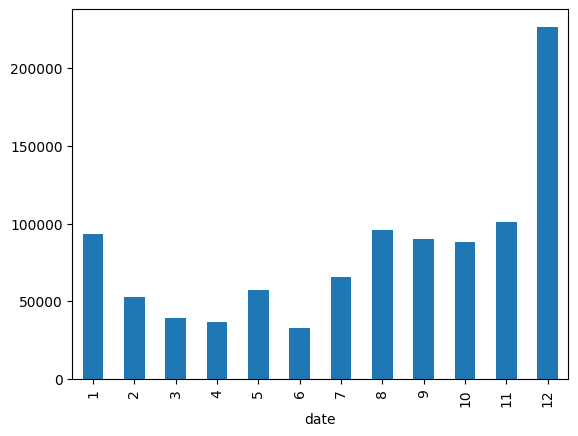

In [5]:
# master_bookings test with Sky on 20

master_bookings['date'] = pd.to_datetime(master_bookings['date'])
res = master_bookings[
    (master_bookings['restaurant_id'] == 4096) &
    (master_bookings['date'] >= "2025-01-01") &
    (master_bookings['date'] < "2026-01-01")
]

monthly = res.groupby(res['date'].dt.month)['package_price'].sum()/100
print(monthly)
monthly.plot(kind='bar')


Find high missing columns: removes if > 95%


In [6]:
# Calculate missing data percentage for each column
missing_stats = pd.DataFrame({
    'column': master_bookings.columns,
    'missing_count': master_bookings.isnull().sum(),
    'missing_percentage': (master_bookings.isnull().sum() / len(master_bookings)) * 100
})

# Sort by missing percentage
missing_stats = missing_stats.sort_values('missing_percentage', ascending=False)

print("\nMissing Data Summary:")
print(missing_stats)



Missing Data Summary:
                                                                          column  \
voucher_id                                                            voucher_id   
deleted_at                                                            deleted_at   
guest_id                                                                guest_id   
refund_guarantee_fee_cents                            refund_guarantee_fee_cents   
refundable_amount_cents                                  refundable_amount_cents   
voucher_added_at                                                voucher_added_at   
email                                                                      email   
phone                                                                      phone   
user_id                                                                  user_id   
medium                                                                    medium   
channel_name                                         

In [7]:
valid_bookings_df = master_bookings.copy()


In [8]:
valid_bookings_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 349385 entries, 0 to 350971
Data columns (total 42 columns):
 #   Column                                   Non-Null Count   Dtype         
---  ------                                   --------------   -----         
 0   updated_at_non_null                      349385 non-null  object        
 1   ack                                      349385 non-null  bool          
 2   active                                   349385 non-null  bool          
 3   arrived                                  349385 non-null  bool          
 4   channel                                  349385 non-null  int64         
 5   created_at                               349385 non-null  object        
 6   created_incremental_refresh              349385 non-null  object        
 7   date                                     349384 non-null  datetime64[ns]
 8   deleted_at                               0 non-null       float64       
 9   email                          

* Change denomination to Dollars
* Convert to booking date, start_time, end_time to datetime
* added day of week


In [9]:
#To convert current Revenue (denominated in cents) into dollars
valid_bookings_df['revenue_dollars'] = (valid_bookings_df['revenue']/100).round(2)
valid_bookings_df.drop(columns=['revenue'], inplace=True)

# Convert date and time columns to appropriate formats
valid_bookings_df['booking_date'] = pd.to_datetime(valid_bookings_df['date'], errors='coerce')
valid_bookings_df['start_time'] = pd.to_datetime(valid_bookings_df['start_time'], format="%H:%M", errors='coerce').dt.time
valid_bookings_df['end_time'] = pd.to_datetime(valid_bookings_df['end_time'], format="%H:%M", errors='coerce').dt.time
valid_bookings_df.drop(columns=['date'], inplace=True)
# Add weekday number (0=Monday, 6=Sunday)
valid_bookings_df['day_of_week_index'] = pd.to_datetime(valid_bookings_df['booking_date']).dt.weekday

# Add weekday name
valid_bookings_df['day_of_week'] = pd.to_datetime(valid_bookings_df['booking_date']).dt.day_name()


KeyError: 'start_time'

* removes if kids less than 0 or more than 100
* removes if adults less than 0 or more than 1000
* removes if revenue > 10000


In [ ]:
# # Define custom outlier conditions -- to determine our outliers based on Hungry Hub's requests/negative values/extreme values
# valid_bookings_df['is_outlier'] = False
# valid_bookings_df['outlier_reason'] = ''

# # Kids outliers: < 0 or > 100
# kids_outliers = (valid_bookings_df['kids'] < 0) | (valid_bookings_df['kids'] > 100)
# valid_bookings_df.loc[kids_outliers, 'is_outlier'] = True
# valid_bookings_df.loc[kids_outliers, 'outlier_reason'] += 'kids_invalid; '

# # Adults outliers: < 0 or > 1000
# adults_outliers = (valid_bookings_df['adult'] < 0) | (valid_bookings_df['adult'] > 1000)
# valid_bookings_df.loc[adults_outliers, 'is_outlier'] = True
# valid_bookings_df.loc[adults_outliers, 'outlier_reason'] += 'adults_invalid; '

# # Revenue outliers: > 10000
# revenue_outliers = valid_bookings_df['revenue_dollars'] > 10000
# valid_bookings_df.loc[revenue_outliers, 'is_outlier'] = True
# valid_bookings_df.loc[revenue_outliers, 'outlier_reason'] += 'revenue_high; '

# # Summary
# print("="*60)
# print("OUTLIER DETECTION SUMMARY")
# print("="*60)
# print(f"Total records: {len(valid_bookings_df):,}")
# print(f"Total outliers: {valid_bookings_df['is_outlier'].sum():,} ({valid_bookings_df['is_outlier'].sum()/len(valid_bookings_df)*100:.2f}%)")
# print()

# # Breakdown by type
# print("Outlier breakdown:")
# print(f"  Kids outliers (< 0 or > 100): {kids_outliers.sum():,}")
# print(f"  Adults outliers (< 0 or > 1000): {adults_outliers.sum():,}")
# print(f"  Revenue outliers (> $10000): {revenue_outliers.sum():,}")
# print()

# # Detailed statistics
# outliers_df = valid_bookings_df[valid_bookings_df['is_outlier'] == True]

# print("="*60)
# print("KIDS OUTLIERS")
# print("="*60)
# kids_out = valid_bookings_df[kids_outliers]
# if len(kids_out) > 0:
#     print(f"Negative kids: {(kids_out['kids'] < 0).sum()}")
#     print(f"Kids > 10: {(kids_out['kids'] > 10).sum()}")
#     print(f"Max kids value: {kids_out['kids'].max()}")
#     print(f"Min kids value: {kids_out['kids'].min()}")
#     print("\nSample:")
#     print(kids_out[['id', 'booking_date', 'kids', 'adult', 'revenue_dollars']].sort_values('kids', ascending=False).head(10))

# print ()


In [ ]:
# print()
# print("="*60)
# print("ADULTS OUTLIERS")
# print("="*60)
# adults_out = valid_bookings_df[adults_outliers]
# if len(adults_out) > 0:
#     print(f"Negative adults: {(adults_out['adult'] < 0).sum()}")
#     print(f"Adults > 50: {(adults_out['adult'] > 45).sum()}")
#     print(f"Max adults value: {adults_out['adult'].max()}")
#     print(f"Min adults value: {adults_out['adult'].min()}")
#     print("\nSample:")
#     print(adults_out[['id', 'booking_date', 'kids', 'adult', 'revenue_dollars']].sort_values('adult', ascending=True).head(10))


In [ ]:
# print()
# print("="*60)
# print("REVENUE OUTLIERS")
# print("="*60)
# revenue_out = valid_bookings_df[revenue_outliers]
# if len(revenue_out) > 0:
#     print(f"Count: {len(revenue_out):,}")
#     print(f"Max revenue: ${revenue_out['revenue_dollars'].max():,.2f}")
#     print(f"Mean of outliers: ${revenue_out['revenue_dollars'].mean():,.2f}")
#     print(f"Median of outliers: ${revenue_out['revenue_dollars'].median():,.2f}")
#     print("\nTop 10 by revenue:")
#     print(revenue_out[['id', 'booking_date', 'kids', 'adult', 'revenue_dollars']].sort_values('revenue_dollars', ascending=False).head(10))

# # View all outliers sorted
# print()
# print("="*60)
# print("ALL OUTLIERS (Top 10)")
# print("="*60)
# print(outliers_df[['id', 'booking_date', 'kids', 'adult', 'revenue_dollars', 'outlier_reason']].head(10))


In [ ]:
valid_bookings_df['restaurant_id']


* aggregate restaurant level


In [ ]:
#Start of restaurant-level aggregation, feature engineering right now currently includes just the aggregation of numeric features. 
#One possible enhancement is to include categorical features

from scipy import stats
from sklearn.preprocessing import StandardScaler

# Create total_guests if not exists
if 'total_guests' not in valid_bookings_df.columns:
    valid_bookings_df['total_guests'] = valid_bookings_df['adult'] + valid_bookings_df['kids']

# Create revenue_per_guest if not exists
if 'revenue_per_guest' not in valid_bookings_df.columns:
    valid_bookings_df['revenue_per_guest'] = (valid_bookings_df['revenue_dollars'] / valid_bookings_df['total_guests']).replace([np.inf, -np.inf], 0).fillna(0).round(2)

# restaurant-level aggregation
restaurant_agg = valid_bookings_df.groupby('restaurant_id').agg({
    'id': 'count',
    'revenue_dollars': ['sum', 'mean', 'median', 'std', 'min', 'max'],
    'adult': ['sum', 'mean', 'median'],
    'kids': ['sum', 'mean', 'median'],
    'total_guests': ['sum', 'mean', 'median', 'std'],
    'revenue_per_guest': ['mean', 'median', 'std'],
    'booking_date': ['min', 'max', 'nunique'],
    'day_of_week': lambda x: x.mode()[0] if len(x.mode()) > 0 else None,  # Most common day
    'start_time': ['min', 'max']
}).round(2)

# Flatten column names
restaurant_agg.columns = ['_'.join(col).strip() for col in restaurant_agg.columns.values]
restaurant_agg = restaurant_agg.reset_index()


In [ ]:
import numpy as np
import pandas as pd

# -----------------------------
# 0) Ensure categorical columns exist + are clean
# -----------------------------
categorical_cols = [
    "medium",
    "arrived",
    "has_special_request",
    "has_promptpay",
    "has_cc",
    "has_shopee_pay",
    "has_alipay",
    "has_wechat_pay",
    "has_true_wallet",
]

# Keep only cols that actually exist (prevents KeyError)
categorical_cols = [c for c in categorical_cols if c in valid_bookings_df.columns]

# Optional: standardize booleans to True/False (helps OHE consistency)
bool_like = [c for c in categorical_cols if c != "medium"]
for c in bool_like:
    valid_bookings_df[c] = valid_bookings_df[c].astype("bool", errors="ignore")

# Optional: fill missing medium as "unknown" so it gets its own bucket
if "medium" in categorical_cols:
    valid_bookings_df["medium"] = valid_bookings_df["medium"].fillna("unknown").astype(str)

# -----------------------------
# 1) One-hot encode booking-level categorical vars
# -----------------------------
group_var = "restaurant_id"

bookings_ohe = pd.get_dummies(
    valid_bookings_df[[group_var] + categorical_cols].copy(),
    columns=categorical_cols,
    prefix=categorical_cols,
    prefix_sep="__",
    dummy_na=False,
)

# Grab ONLY the dummy columns we created
dummy_cols = [c for c in bookings_ohe.columns if c != group_var]

# -----------------------------
# 2) Aggregate dummies per restaurant: mean + sum
#    - mean => "share of bookings with that attribute"
#    - sum  => "count of bookings with that attribute"
# -----------------------------
cat_grouped = bookings_ohe.groupby(group_var)[dummy_cols].agg(["mean", "sum"])

# Flatten columns into <dummy>_count_norm and <dummy>_count
cat_grouped.columns = [
    f"{col}_count_norm" if stat == "mean" else f"{col}_count"
    for col, stat in cat_grouped.columns
]
cat_grouped = cat_grouped.reset_index()

# -----------------------------
# 3) Merge into your restaurant_agg
# -----------------------------
restaurant_agg = restaurant_agg.merge(
    cat_grouped,
    on="restaurant_id",
    how="left",
)

# If a restaurant somehow has no rows in cat_grouped, fill 0 for those dummy aggregations
new_cat_cols = [c for c in restaurant_agg.columns if c.endswith("_count") or c.endswith("_count_norm")]
restaurant_agg[new_cat_cols] = restaurant_agg[new_cat_cols].fillna(0)

restaurant_agg.head()


In [ ]:
restaurant_agg.info()


In [ ]:
restaurants.info()


In [ ]:
restaurant_agg = restaurant_agg.merge(restaurants, left_on='restaurant_id', right_on='restaurant_id', how='left')
restaurant_agg.head()


In [ ]:
restaurant_agg.info()


In [ ]:
restaurant_agg.columns
# Rename for clarity need to update now that there are more columns
rename_dict = {
    'id_count': 'total_bookings',
    'revenue_dollars_sum': 'total_revenue',
    'revenue_dollars_mean': 'avg_revenue_per_booking',
    'revenue_dollars_median': 'median_revenue_per_booking',
    'revenue_dollars_std': 'revenue_std',
    'revenue_dollars_min': 'min_revenue',
    'revenue_dollars_max': 'max_revenue',
    'adult_sum': 'total_adults',
    'adult_mean': 'avg_adults',
    'adult_median': 'median_adults',
    'kids_sum': 'total_kids',
    'kids_mean': 'avg_kids',
    'kids_median': 'median_kids',
    'total_guests_sum': 'total_guests_sum',
    'total_guests_mean': 'avg_party_size',
    'total_guests_median': 'median_party_size',
    'total_guests_std': 'party_size_std',
    'revenue_per_guest_mean': 'avg_revenue_per_guest',
    'revenue_per_guest_median': 'median_revenue_per_guest',
    'revenue_per_guest_std': 'revenue_per_guest_std',
    'booking_date_min': 'first_booking',
    'booking_date_max': 'last_booking',
    'booking_date_nunique': 'unique_booking_days',
    'day_of_week_<lambda>': 'most_popular_day_of_week',
    'start_time_min': 'earliest_booking_time',
    'start_time_max': 'latest_booking_time'

}

restaurant_agg.rename(columns=rename_dict, inplace=True)

restaurant_agg.head()


In [ ]:
#remove outliers from restaurant_id based on google sheet 
outlier_ids = [4503, 4502, 933, 837]
restaurant_agg = restaurant_agg[~restaurant_agg['restaurant_id'].isin(outlier_ids)]
restaurant_agg.shape


In [ ]:
# Monthly revenue split: Jan 1, 2025 (inclusive) to Jan 1, 2026 (exclusive)
start_date = pd.Timestamp("2025-01-01")
end_date = pd.Timestamp("2026-01-01")

# Ensure datetime
valid_bookings_df["booking_date"] = pd.to_datetime(valid_bookings_df["booking_date"], errors="coerce")

# Filter to requested window
bookings_2025 = valid_bookings_df[
    (valid_bookings_df["booking_date"] >= start_date) &
    (valid_bookings_df["booking_date"] < end_date)
].copy()

# Build month key
bookings_2025["month"] = bookings_2025["booking_date"].dt.to_period("M").astype(str)

# Aggregate monthly revenue by restaurant
monthly_rev = (
    bookings_2025
    .groupby(["restaurant_id", "month"], as_index=False)["revenue_dollars"]
    .sum()
)

# Pivot to wide format (one column per month)
all_months = pd.period_range("2025-01", "2025-12", freq="M").astype(str)
monthly_rev_wide = (
    monthly_rev
    .pivot(index="restaurant_id", columns="month", values="revenue_dollars")
    .reindex(columns=all_months, fill_value=0)
    .reset_index()
)

# Rename columns to clear names
monthly_rev_wide = monthly_rev_wide.rename(
    columns={m: f"revenue_{m.replace('-', '_')}" for m in all_months}
)

# Merge into restaurant_agg
restaurant_agg = restaurant_agg.merge(monthly_rev_wide, on="restaurant_id", how="left")

# Fill missing monthly values with 0
new_month_cols = [c for c in restaurant_agg.columns if c.startswith("revenue_2025_")]
restaurant_agg[new_month_cols] = restaurant_agg[new_month_cols].fillna(0)

# View monthly breakdown for restaurant_id = 4506
restaurant_agg.loc[
    restaurant_agg["restaurant_id"] == 4096,
    ['name', "restaurant_id", "total_revenue"] + new_month_cols
]


In [ ]:
import pandas as pd
import re

def extract_city_robust(row):
    address = str(row.get('formatted_address', ''))
    country = str(row.get('country', ''))

    # 1. Handle Singapore (City-State)
    if 'Singapore' in country or 'Singapore' in address:
        return 'Singapore'

    # 2. Handle Hong Kong
    if 'Hong Kong' in country or 'Hong Kong' in address:
        return 'Hong Kong'

    # 3. Handle Thailand
    # Detect Bangkok (Standard English, Thai, or Formal Name)
    if re.search(r'Krung Thep Maha Nakhon|Bangkok|กรุงเทพมหานคร', address, re.IGNORECASE):
        return 'Bangkok'

    # Detect Thai Provinces (Format: "Chang Wat [Name]")
    match_changwat = re.search(r'Chang Wat\s+([a-zA-Z\s]+?)(?=\s\d|,|$)', address, re.IGNORECASE)
    if match_changwat:
        return match_changwat.group(1).strip()

    # 4. Handle USA (Format: "City, State Zip")
    # Captures the text before the State Abbreviation (2 caps) and Zip (5 digits)
    if 'United States' in country or 'USA' in address:
        match_us = re.search(r',\s*([^,]+?),\s*[A-Z]{2}\s+\d{5}', address)
        if match_us:
            return match_us.group(1).strip()

    # 5. Fallback Heuristic (Word before Zip Code)
    # Useful for non-standard formats; grabs the last significant text block before the 5-digit zip
    match_zip = re.search(r',\s*([a-zA-Z\s]+?)\s+\d{5}', address)
    if match_zip:
        return match_zip.group(1).strip()

    return "" # Leave blank if undetermined

# Load the file
google_restaurants_df = pd.read_csv('data_output/places_api_new_results.csv')

# Apply the extraction
google_restaurants_df['city'] = google_restaurants_df.apply(extract_city_robust, axis=1)

# # Save the cleaned file
# output_filename = 'cleaned_places_results.csv'
# google_restaurants_df.to_csv(output_filename, index=False)

# print(f"Success! '{output_filename}' has been created.")
# print(google_restaurants_df[['formatted_address', 'city']].head(10)) # Preview


In [ ]:
# google_restaurants_df[google_restaurants_df['country'] == 'Thailand']['city'].value_counts()
#generate plots for unique cities distribution for restaurants
import matplotlib.pyplot as plt
import seaborn as sns
# --- Plot 1: Top 20 Cities ---
city_counts = google_restaurants_df['city'].value_counts().head(20).reset_index()
city_counts.columns = ['City', 'Count']

plt.figure(figsize=(12, 8))
sns.barplot(data=city_counts, x='Count', y='City', palette='viridis')
plt.title('Top 20 Cities by Restaurant Count')
plt.xlabel('Number of Restaurants')
plt.show()

# --- Plot 2: Country Distribution ---
country_counts = google_restaurants_df['country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=country_counts.head(10), x='Count', y='Country', palette='magma')
plt.title('Top 10 Countries by Restaurant Count')
plt.xlabel('Number of Restaurants')
plt.show()


In [ ]:
# Filter the DataFrame to strictly keep 'Thailand'
google_restaurants_df = google_restaurants_df[google_restaurants_df['country'] == 'Thailand']

# 3. Verify the filter worked
print("\n--- After Filtering ---")
print(google_restaurants_df['country'].value_counts())


In [ ]:
import seaborn as sns
# 2. Define the Hierarchy Extraction Logic
def extract_cuisine_hierarchy(row):
    # Combine 'official_name' and 'input_string' for maximum context
    text = (str(row.get('official_name', '')) + " " + str(row.get('input_string', ''))).lower()

    major = 'Uncategorized'
    sub = 'General'

    # --- JAPANESE ---
    if re.search(r'japanese|sushi|ramen|izakaya|omakase|yakiniku|tempura|udon|soba|donburi|teppanyaki|shabu|sukiyaki', text):
        major = 'Japanese'
        if 'sushi' in text: sub = 'Sushi'
        elif 'ramen' in text: sub = 'Ramen'
        elif 'omakase' in text: sub = 'Omakase'
        elif 'izakaya' in text: sub = 'Izakaya'
        elif 'yakiniku' in text or 'bbq' in text: sub = 'Yakiniku/BBQ'
        elif 'shabu' in text or 'sukiyaki' in text or 'nabe' in text: sub = 'Shabu/Hotpot'
        elif 'tempura' in text: sub = 'Tempura'
        else: sub = 'General Japanese'

    # --- CHINESE ---
    elif re.search(r'chinese|dim sum|hotpot|mala|hong kong|duck|cantonese|shabu', text):
        major = 'Chinese'
        if 'dim sum' in text: sub = 'Dim Sum'
        elif 'mala' in text: sub = 'Mala'
        elif 'hotpot' in text: sub = 'Hotpot'
        elif 'duck' in text: sub = 'Roast Duck'
        else: sub = 'General Chinese'

    # --- ITALIAN ---
    elif re.search(r'italian|pizza|pasta|cucina|ristorante|spaghetti', text):
        major = 'Italian'
        if 'pizza' in text: sub = 'Pizza'
        elif 'pasta' in text or 'spaghetti' in text: sub = 'Pasta'
        else: sub = 'General Italian'

    # --- STEAKHOUSE / BBQ ---
    elif re.search(r'steak|grill|meat|beef|bbq|ribs|wagyu', text):
        major = 'Steakhouse/BBQ'
        if 'steak' in text or 'wagyu' in text or 'beef' in text: sub = 'Steakhouse'
        elif 'bbq' in text or 'ribs' in text: sub = 'BBQ'
        else: sub = 'General Grill'

    # --- CAFE / BAKERY ---
    elif re.search(r'cafe|café|coffee|bakery|dessert|cake|tea|brunch|bistro|pastry', text):
        major = 'Cafe/Bakery'
        if 'coffee' in text or 'roast' in text: sub = 'Coffee Shop'
        elif 'bakery' in text or 'pastry' in text or 'cake' in text: sub = 'Bakery/Dessert'
        elif 'tea' in text: sub = 'Tea House'
        elif 'brunch' in text: sub = 'Brunch'
        else: sub = 'General Cafe'

    # --- BAR / NIGHTLIFE ---
    elif re.search(r'bar|pub|lounge|club|rooftop|beer|wine|cocktail', text):
        major = 'Bar/Nightlife'
        if 'rooftop' in text or 'sky' in text: sub = 'Rooftop Bar'
        elif 'wine' in text: sub = 'Wine Bar'
        elif 'pub' in text or 'beer' in text: sub = 'Pub/Beer'
        elif 'club' in text: sub = 'Club/Lounge'
        else: sub = 'General Bar'

    # --- SEAFOOD ---
    elif re.search(r'seafood|crab|fish|lobster|oyster|shrimp', text):
        major = 'Seafood'
        if 'crab' in text: sub = 'Crab Specialist'
        elif 'oyster' in text: sub = 'Oyster Bar'
        else: sub = 'General Seafood'

    # --- THAI ---
    elif re.search(r'thai|siam|nara|som tum|tomyum|baan', text):
        major = 'Thai'
        if 'som tum' in text: sub = 'Som Tum (Papaya Salad)'
        elif 'boat noodle' in text: sub = 'Boat Noodles'
        else: sub = 'General Thai'

    return pd.Series([major, sub], index=['major_cuisine', 'sub_cuisine'])

# 3. Apply Function & Save
google_restaurants_df[['major_cuisine', 'sub_cuisine']] = google_restaurants_df.apply(extract_cuisine_hierarchy, axis=1)

# 4. Generate Visualizations (Subplots)
# Filter data to remove 'Uncategorized' and focus on Top 6 Major Cuisines
breakdown = google_restaurants_df[google_restaurants_df['major_cuisine'] != 'Uncategorized'].copy()
top_majors = breakdown['major_cuisine'].value_counts().head(6).index
# filtered_data = breakdown[breakdown['major_cuisine'].isin(top_majors)]

# Initialize Subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Loop through top 6 cuisines and plot their sub-types
for i, cuisine in enumerate(top_majors):
    ax = axes[i]
    subset = breakdown[breakdown['major_cuisine'] == cuisine]
    sub_counts = subset['sub_cuisine'].value_counts()

    sns.barplot(x=sub_counts.values, y=sub_counts.index, ax=ax, palette='viridis')
    ax.set_title(f'{cuisine} Breakdown', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Restaurants')

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# 1. Count the occurrences of each cuisine in Thailand
# We take the top 15 to prevent the chart from becoming unreadable with tiny categories
cuisines = breakdown['major_cuisine'].value_counts().head(15)

plt.figure(figsize=(10, 8))

# 2. Generate a Horizontal Bar Chart
# Sort values ascending so the biggest bar ends up at the top of the plot
cuisines.sort_values().plot(kind='barh', color='#2ecc71', edgecolor='black')

# 3. Formatting
plt.title('Top 15 Cuisines in Thailand', fontsize=16)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Cuisine', fontsize=12)

# Optional: Add the exact numbers to the end of each bar
for index, value in enumerate(cuisines.sort_values()):
    plt.text(value, index, f' {value}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
restaurant_agg = restaurant_agg.merge(google_restaurants_df, left_on='name', right_on='input_string', how='left')
restaurant_agg.head()


In [ ]:
restaurant_agg[['name', 'country', 'total_revenue']].head()


In [ ]:
restaurant_agg.columns


In [ ]:
# Add cuisine from Places results
places_df = pd.read_csv("data_output/places_api_new_results.csv")


In [ ]:
places_cuisine = places_df[["input_string", "Cuisine", "Cuisine_confidence"]].drop_duplicates()

if "input_string" in restaurant_agg.columns:
    restaurant_agg = restaurant_agg.merge(places_cuisine, on="input_string", how="left")
elif "name" in restaurant_agg.columns:
    restaurant_agg = restaurant_agg.merge(
        places_cuisine,
        left_on="name",
        right_on="input_string",
        how="left"
    )
    restaurant_agg.drop(columns=["input_string"], inplace=True)
else:
    print("Warning: no join key (input_string or name) found in restaurant_agg")

restaurant_agg.head()
